In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [102]:

import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "real_estate_analytics.csv"
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "namishsharma/real-estate-analytics-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()



/tmp/ipykernel_2032/1289051362.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:    Sale_Price_USD  House_Size_SqFt  Distance_To_Railway_Station_Km  \
0       337253.56             3260                            6.48   
1       289630.18             2558                           11.05   
2       348576.64             2859                           10.24   
3       414227.24             3525                           14.35   
4       282438.50             2624                           15.23   

   Hospital_Proximity_Score  Pollution_Level  Parking_Available  \
0                       4.4             89.3                  1   
1                       3.5             66.4                  0   
2                       3.7             76.2                  1   
3                       6.7             79.6                  1   
4                       4.9             47.9                  1   

   Property_Age_Years  Lot_Street_Number  
0                29.6                112  
1                15.7                325  
2                 2.6         

,Sale_Price_USD,House_Size_SqFt,Distance_To_Railway_Station_Km,Hospital_Proximity_Score,Pollution_Level,Parking_Available,Property_Age_Years,Lot_Street_Number
0,337253.56,3260,6.48,4.4,89.3,1,29.6,112
1,289630.18,2558,11.05,3.5,66.4,0,15.7,325
2,348576.64,2859,10.24,3.7,76.2,1,2.6,959
3,414227.24,3525,14.35,6.7,79.6,1,47.4,258
4,282438.50,2624,15.23,4.9,47.9,1,32.1,950


In [103]:
df.columns

Index(['Sale_Price_USD', 'House_Size_SqFt', 'Distance_To_Railway_Station_Km',
       'Hospital_Proximity_Score', 'Pollution_Level', 'Parking_Available',
       'Property_Age_Years', 'Lot_Street_Number'],
      dtype='object')

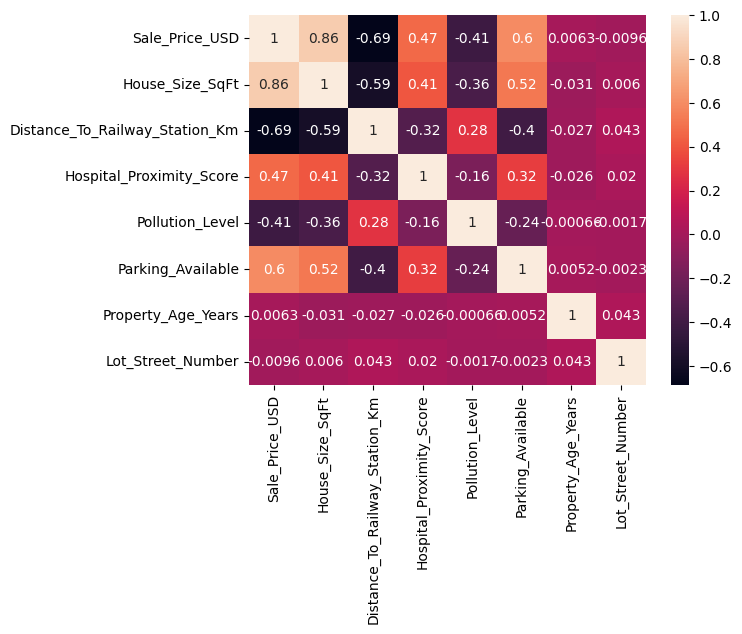

In [104]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.show()

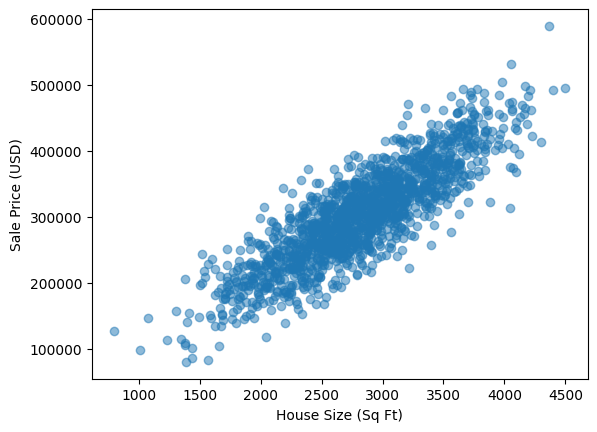

In [105]:
plt.scatter(
    df["House_Size_SqFt"],
    df["Sale_Price_USD"],
    alpha=0.5
)

plt.xlabel("House Size (Sq Ft)")
plt.ylabel("Sale Price (USD)")
plt.show()

In [106]:
X = df[
    [
        "House_Size_SqFt",
        "Distance_To_Railway_Station_Km",
        "Hospital_Proximity_Score",
        "Parking_Available",
        "Pollution_Level"
    ]
]

y = df["Sale_Price_USD"]

In [107]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [108]:
model = LinearRegression()

In [109]:
model.fit(X_train, y_train)

LinearRegression()

In [110]:
predictions = model.predict(X_test)
print(predictions[:5])
print(y_test.head().values)

[428295.96764676 289386.20558605 249184.31827486 407164.72887643
 410977.22931535]
[480256.17 266753.83 281327.69 395825.76 371635.67]


In [111]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R²:", r2)

MAE: 24485.731103888902
R²: 0.8217274661081244


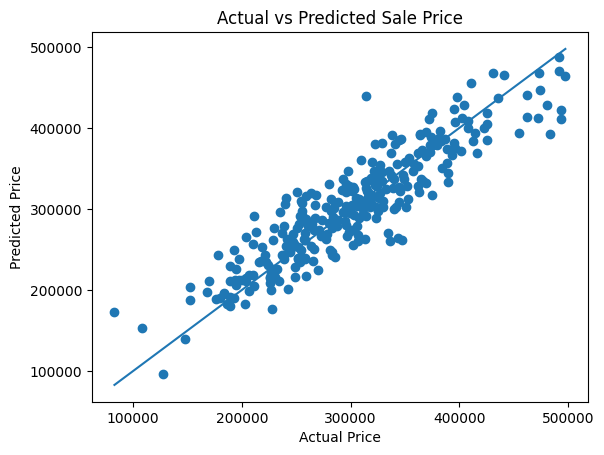

In [112]:
plt.scatter(y_test, predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Sale Price")

plt.show()

# RANDOM FOREST

In [113]:
median_price = df["Sale_Price_USD"].median()
mean_price= df["Sale_Price_USD"].mean()
print("median", median_price)
print("mean", mean_price)
df["High_Value"] = (
    df["Sale_Price_USD"] >= median_price
).astype(int)
df["High_Value"].value_counts()

median 303780.225
mean 303694.11275333335


,count
High_Value,
1,750
0,750


In [114]:
X = df[
    [
        "House_Size_SqFt",
        "Distance_To_Railway_Station_Km",
        "Hospital_Proximity_Score",
        "Parking_Available",
        "Pollution_Level"
    ]
]

y = df["High_Value"]

In [115]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [116]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [117]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [118]:
predictions = model.predict(X_test)
print(predictions[:10])
print(y_test.head(10).values)

[1 0 0 1 1 0 0 0 0 1]
[1 0 0 1 1 0 0 0 0 1]


In [119]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.8333333333333334


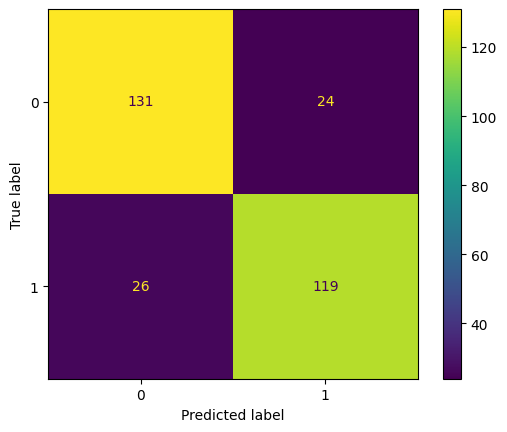

In [120]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions
)

plt.show()

# K-Means Clustering


In [121]:
X = df[
    [
        "House_Size_SqFt",
        "Distance_To_Railway_Station_Km",
        "Hospital_Proximity_Score",
        "Parking_Available",
        "Pollution_Level"
    ]
]

In [122]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [123]:
from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

In [124]:
clusters = kmeans.fit_predict(X_scaled)
df["Cluster"] = clusters

In [125]:
df["Cluster"].value_counts()

,count
Cluster,
1,594
2,511
0,395


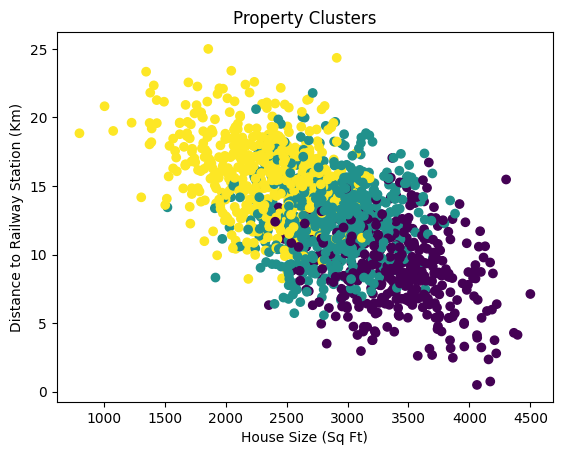

In [126]:
plt.scatter(
    df["House_Size_SqFt"],
    df["Distance_To_Railway_Station_Km"],
    c=df["Cluster"]
)

plt.xlabel("House Size (Sq Ft)")
plt.ylabel("Distance to Railway Station (Km)")
plt.title("Property Clusters")

plt.show()

In [127]:
df.groupby("Cluster")[
    [
        "House_Size_SqFt",
        "Distance_To_Railway_Station_Km",
        "Hospital_Proximity_Score",
        "Parking_Available",
        "Pollution_Level"
    ]
].mean()

,House_Size_SqFt,Distance_To_Railway_Station_Km,Hospital_Proximity_Score,Parking_Available,Pollution_Level
Cluster,,,,,
0,3400.321519,8.951190,6.416962,0.929114,68.243797
1,2873.425926,12.799175,5.220034,0.609428,80.525758
2,2298.900196,15.854677,4.398043,0.017613,91.572407
